# Notebook 1 : Vitesses sur les faces

**Objectif** : à partir du potentiel φ (disponible au notebook 0) et de la carte du labyrinthe, calculer les vitesses normales sur les faces des cellules.

**Fichiers utilisés** : `out_pot.npy` et `out_domain.txt`.
**Fichiers produits** : `U.npy` et `V.npy`.

## 1. Chargement des données

In [6]:
import os

os.chdir(r"C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire")

print(os.getcwd())

C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('figures', exist_ok=True)

phi = np.load('out_pot.npy')                    # potentiel, aux centres des cellules
dom = np.loadtxt('out_domain.txt', dtype=int)   # 0 = mur, 1 = fluide, 2 = entrée/sortie
Ny, Nx = phi.shape
dx = dy = 1.0                                   # pixels carrés de côté 1
fluid = dom > 0                                 # masque booléen : True si fluide (1 ou 2), False si mur (0)

print("taille de la grille :", Ny, "lignes x", Nx, "colonnes")
print("valeurs dans dom :", np.unique(dom))
print("cellules fluides :", fluid.sum(), "sur", dom.size)

taille de la grille : 502 lignes x 502 colonnes
valeurs dans dom : [0 1 2]
cellules fluides : 209276 sur 252004


`fluid = dom > 0` donne un tableau de True/False de la même taille que `dom` : True pour les cellules 1 et 2, False pour les murs.

## 2. Les tableaux de vitesses

Il y a toujours une face de plus que de cellules dans une direction (N cellules = N+1 faces) :
- `U[i, j]` : vitesse sur la face **gauche** de la cellule (i, j). Sa face droite est `U[i, j+1]`. Taille (Ny, Nx+1).
- `V[i, j]` : vitesse sur la face **haute** de la cellule (i, j). Sa face basse est `V[i+1, j]`. Taille (Ny+1, Nx).

`i` augmente vers le bas de l'image : **V > 0 veut dire vers le bas**.

In [10]:
U = np.zeros((Ny, Nx + 1))
V = np.zeros((Ny + 1, Nx))

## 3. Faces internes (entre deux cellules)

La vitesse d'une face est la pente de φ entre les deux cellules voisines : `U = -(φ_droite - φ_gauche) / dx`. Le signe moins vient de ce fichier : le fluide va des φ élevés vers les φ bas.

On ne calcule la vitesse que si **les deux cellules sont fluides**. Si l'une est un mur, la face reste à 0 : aucun flux ne traverse une paroi (imperméabilité). Sans ce test, on obtiendrait une fausse vitesse à travers le mur, parce que φ n'a pas de sens physique dans un mur.

In [12]:
# faces verticales (U) : on compare chaque cellule à sa voisine de droite
face_U = fluid[:, 1:] & fluid[:, :-1]
U[:, 1:Nx] = np.where(face_U, -(phi[:, 1:] - phi[:, :-1]) / dx, 0.0)

# faces horizontales (V) : on compare chaque cellule à sa voisine du dessous
face_V = fluid[1:, :] & fluid[:-1, :]
V[1:Ny, :] = np.where(face_V, -(phi[1:, :] - phi[:-1, :]) / dy, 0.0)

## 4. Faces d'entrée et de sortie

Les cellules d'entrée et de sortie ont une face sans voisin fluide, donc pas de différence de φ possible. On impose la continuité dans la cellule : ce qui entre par une face ressort par l'autre.

Le code suppose que l'entrée est en haut de l'image (ligne la plus haute contenant des 2) et la sortie en bas (ligne la plus basse contenant des 2).

In [23]:
rows_bc = np.where((dom == 2).any(axis=1))[0]
i_in, i_out = rows_bc.min(), rows_bc.max()
j_in  = np.where(dom[i_in, :]  == 2)[0]
j_out = np.where(dom[i_out, :] == 2)[0]

V[i_in, j_in]        = V[i_in + 1, j_in]     # entrée : face haute = face basse
V[i_out + 1, j_out]  = V[i_out, j_out]       # sortie : face basse = face haute

print("entrée : ligne", i_in, ", colonnes", j_in)
print("sortie : ligne", i_out, ", colonnes", j_out)

entrée : ligne 1 , colonnes [228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248]
sortie : ligne 500 , colonnes [253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270
 271 272 273]


## 5. Normalisation

On divise tout par la vitesse maximale, donc max(|U|, |V|) = 1. L'échelle de φ est arbitraire, et l'équation d'advection est linéaire en vitesse : cela change seulement l'unité de temps. Les temps d'arrivée seront donc en unités de « cellules / vitesse max ». 
Cela pour simplifier les calculs.

In [37]:
vmax = max(np.abs(U).max(), np.abs(V).max())
print("vitesse max avant normalisation :", vmax)
U /= vmax
V /= vmax

np.save('U.npy', U)
np.save('V.npy', V)
print("U.npy et V.npy sauvegardés")

vitesse max avant normalisation : 1.0
U.npy et V.npy sauvegardés


## 6. Contrôles

Divergence de chaque cellule : (U_droite − U_gauche)/dx + (V_bas − V_haut)/dy. 

Pour un fluide incompressible elle vaut 0. Elle n'est pas exactement nulle parce que φ n'est qu'une solution approchée de Laplace (tolérance du solveur). Les vitesses étant normalisées à 1, la valeur est relative à la vitesse max.

In [40]:
div = (U[:, 1:] - U[:, :-1]) / dx + (V[1:, :] - V[:-1, :]) / dy
inner = dom == 1                                  # cellules fluides intérieures

print("Divergence max (cellules intérieures)  :", np.abs(div[inner]).max())
print("Divergence moyenne (valeur absolue)    :", np.abs(div[inner]).mean())
i_m, j_m = np.unravel_index(np.argmax(np.abs(div) * inner), div.shape)
print("Position du maximum (ligne, colonne)   :", (i_m, j_m))
print("Divergence max aux cellules d'entrée/sortie :", np.abs(div[dom == 2]).max())

Divergence max (cellules intérieures)  : 7.337315379275551e-13
Divergence moyenne (valeur absolue)    : 7.724308697406733e-14
Position du maximum (ligne, colonne)   : (98, 179)
Divergence max aux cellules d'entrée/sortie : 0.0


**Débits** : somme des vitesses sur les faces d'entrée et de sortie. Ils doivent être égaux (conservation globale de la masse).

In [43]:
Q_in  = V[i_in, j_in].sum() * dx
Q_out = V[i_out + 1, j_out].sum() * dx
print("Débit entrant :", Q_in)
print("Débit sortant :", Q_out)
print("Écart relatif :", abs(Q_in - Q_out) / abs(Q_in))
print("Sens de l'écoulement entrée -> sortie :", "OK" if (Q_in > 0 and Q_out > 0) else "A VÉRIFIER (signe de φ ?)")

Débit entrant : 6.9974524061117584
Débit sortant : 6.997452403851093
Écart relatif : 3.2306978331929336e-10
Sens de l'écoulement entrée -> sortie : OK


**Parois imperméables** : toutes les faces entre une cellule fluide et un mur doivent avoir une vitesse nulle, ainsi que les faces du bord de l'image (sauf entrée et sortie).

In [46]:
print("max |U| sur faces contre un mur :", np.abs(U[:, 1:Nx][~face_U]).max())
print("max |V| sur faces contre un mur :", np.abs(V[1:Ny, :][~face_V]).max())
print("max |U| sur les bords gauche/droit de l'image :", max(np.abs(U[:, 0]).max(), np.abs(U[:, Nx]).max()))
bord_V = np.concatenate([V[0, :], V[Ny, :]])
bord_V_hors_BC = np.concatenate([np.delete(V[0, :], j_in) if i_in == 0 else V[0, :],
                                 np.delete(V[Ny, :], j_out) if i_out == Ny - 1 else V[Ny, :]])
print("max |V| sur les bords haut/bas (hors entrée/sortie) :", np.abs(bord_V_hors_BC).max())

max |U| sur faces contre un mur : 0.0
max |V| sur faces contre un mur : 0.684407743803207
max |U| sur les bords gauche/droit de l'image : 0.0
max |V| sur les bords haut/bas (hors entrée/sortie) : 0.0


## 7. Visualisation

On trace la norme de la vitesse (au centre des cellules, moyenne des deux faces) et des flèches. Le fluide doit suivre les bras, de l'entrée vers la sortie, et accélérer dans les passages étroits et les coins.

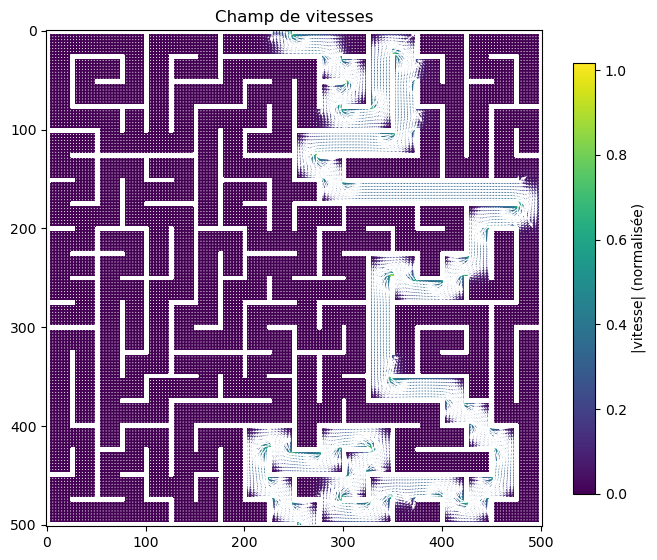

In [49]:
uc = 0.5 * (U[:, :-1] + U[:, 1:])             # vitesse au centre des cellules (affichage seulement)
vc = 0.5 * (V[:-1, :] + V[1:, :])
speed = np.where(fluid, np.hypot(uc, vc), np.nan)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(speed)
plt.colorbar(im, ax=ax, shrink=0.7, label="|vitesse| (normalisée)")
s = 3                                          # une flèche sur s
Y, X = np.mgrid[0:Ny:s, 0:Nx:s]
ax.quiver(X, Y, uc[::s, ::s], vc[::s, ::s], angles='xy', color='w')
ax.set_title("Champ de vitesses")
plt.savefig('figures/vitesses.png', dpi=200, bbox_inches='tight')
plt.show()